# Telco Customer Churn — Exploratory Data Analysis

## What this notebook is for

First look at the raw Telco churn dataset before any of it is trusted downstream.
It has two jobs:

1. **Find out what needs cleaning.** `pipeline/ingest.py` writes into a typed
   PostgreSQL schema (`db/schema.sql`), so every column has to be checked against the
   type it is about to be inserted as. Anything that arrives as text where the schema
   says `BOOLEAN` or `DECIMAL` has to be caught here, not at the `INSERT`.
2. **Find out what is worth modelling.** Which columns look like they separate churners
   from non-churners, and how balanced the target is — that decides the metric
   `models/train.py` is scored on.

Analysis only. Nothing here writes to the database; the cleaning logic that comes out of
it lives in `pipeline/ingest.py`.

## The dataset

**IBM Telco Customer Churn** — `blastchar/telco-customer-churn` on Kaggle, pulled with
`kagglehub`. One row per customer of a fictional telecom company, **7,043 rows × 21
columns**, with a labelled churn outcome.

The columns fall into four groups:

| Group | Columns |
|---|---|
| Identity / demographics | `customerID`, `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Account | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` |
| Services | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Money + label | `MonthlyCharges`, `TotalCharges`, `Churn` |

`Churn` is the target: did this customer leave within the last month.

## Key questions

**On data quality — what has to be fixed before the load:**

- Which columns are actually binary, and are they all encoded the same way?
- Are the numeric columns really numeric, or is something arriving as text?
- Are there missing values, and are they missing in a way `.info()` will report?
- Are there duplicate rows?

**On the churn signal — what to model:**

- How imbalanced is `Churn`? (This decides whether accuracy is a usable metric.)
- Does churn vary by contract type, internet service, or payment method?
- Does `tenure` separate churners from non-churners?
- Are `tenure`, `MonthlyCharges`, and `TotalCharges` collinear — is `TotalCharges`
  just `tenure × MonthlyCharges` restated?

The first group is answered below. The second is started — the class balance is
settled — and the per-segment breakdowns are still to come.


In [1]:
import os

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Shared chart styling, so every figure below matches.
sns.set_theme(style="whitegrid")

ACCENT = "#2a78d6"                                  # single-series bars
CHURN_COLORS = {"No": "#2a78d6", "Yes": "#eb6834"}  # churn / retained

In [2]:
# Download dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset path:", path)
print("Files:", os.listdir(path))

Dataset path: C:\Users\cheth\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
Files: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


### Download — one CSV, cached outside the repo

`kagglehub` resolves to a single file, `WA_Fn-UseC_-Telco-Customer-Churn.csv`, in a
local cache directory rather than in the project.

Two things worth noting:

- **The path is machine-specific** (`C:\Users\cheth\.cache\kagglehub\...`), so this cell
  is not reproducible on another machine as written. That is fine here — `data/raw/` is
  gitignored and the CSV is deliberately not committed — but anything that needs to run
  elsewhere should take the path from config rather than from the cache.
- **`kagglehub` is not in `requirements.txt`.** The notebook imports it, so a fresh
  environment following the README will fail on this cell. It needs adding.


In [3]:
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(csv_file)

### Load — no dtypes given, so pandas guessed

`pd.read_csv` with no `dtype=` argument, which means every column type below is
**inferred from the file contents**, not declared. That inference is what the next few
cells are checking, and it is where the one real surprise in this dataset shows up.

No parse errors and no warnings — whatever is in `TotalCharges`, it was readable as
*something*.


In [4]:
# Columns whose values fit entirely inside {"Yes", "No"} or {0, 1}
for col in df.columns:
    unique_values = set(df[col].dropna().unique())

    if unique_values <= {"Yes", "No"} | {1, 0}:
        print(col)

SeniorCitizen
Partner
Dependents
PhoneService
PaperlessBilling
Churn


### Six binary columns — in two different encodings

The subset test `unique_values <= {"Yes", "No"} | {1, 0}` finds every column whose values
fit inside that combined set:

```
SeniorCitizen
Partner
Dependents
PhoneService
PaperlessBilling
Churn
```

**These six are not encoded the same way.** `SeniorCitizen` is `0`/`1` integers; the other
five are `"Yes"`/`"No"` strings. The scan catches both because the comparison set is the
union of the two vocabularies.

That split is the reason `clean_data()` in `pipeline/ingest.py` uses **two** conversions
rather than one:

```python
df["senior_citizen"] = df["senior_citizen"].astype(bool)          # already 0/1
df[col] = df[col].map({"Yes": True, "No": False})                  # Yes/No strings
```

Using `.astype(bool)` on a Yes/No column would return `True` for **every** non-empty
string — including `"No"` — which would silently destroy the `Churn` label. The scan
above is what establishes which columns go down which path.

Note what this scan does *not* catch: columns like `MultipleLines` and `OnlineSecurity`
are Yes/No-*ish* but carry a third value (`"No phone service"`, `"No internet service"`),
so they fall out of the subset test and stay as `VARCHAR` in the schema. That is
correct — collapsing them to boolean would throw away the distinction between "declined
the service" and "not eligible for it".


In [5]:
print("Shape (rows, columns):", df.shape)

print()
print("First 5 rows:")
print(df.head())

print()
print("Column types and non-null counts:")
df.info()

print()
print("Target balance:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(1))

Shape (rows, columns): (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport

### The two findings that matter

**1. `TotalCharges` is text, not a number.**

```
 18   MonthlyCharges    7043 non-null   float64
 19   TotalCharges      7043 non-null   str
```

`MonthlyCharges` inferred as `float64`; `TotalCharges`, which holds the same kind of
value, did not. A column of numbers only reads as text if at least one entry is not a
number — here, blank strings for customers who have not been billed yet.

And `.info()` **cannot see them**: it reports `7043 non-null` because an empty string is
a perfectly valid string. A null check alone would pass this dataset and let the bad rows
through to a `DECIMAL(10,2)` column. This is exactly why `clean_data()` coerces first and
drops second:

```python
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])
```

`errors="coerce"` turns the unparseable blanks into real `NaN`, which `dropna` can then
remove. The ingest pipeline drops **11 rows** this way — 7,043 in, 7,032 out.

**2. The target is imbalanced.**

```
Churn
No     5174
Yes    1869
```

**26.5% churn, 73.5% retained.** The consequence for `models/train.py`: a model that
predicts "no churn" for every single customer scores **73.5% accuracy** while being
completely useless. Accuracy is not a usable metric on this dataset — training has to be
scored on **PR-AUC and recall on the churn class**, and the imbalance handled with
`class_weight="balanced"` or `scale_pos_weight`.

Also visible: `SeniorCitizen` is `int64` (the `0`/`1` encoding from the previous cell),
and `customerID` is a unique string key — the natural `PRIMARY KEY`, which is how
`db/schema.sql` declares it.


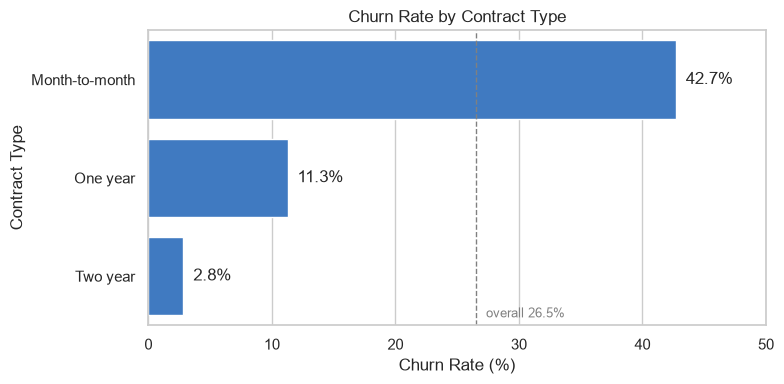

In [6]:
churn_by_contract = df.copy()
churn_by_contract["Churn"] = churn_by_contract["Churn"].map({"Yes": 1, "No": 0})

churn_rates = (
    churn_by_contract.groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="churn_rate")
)
overall_rate = churn_by_contract["Churn"].mean() * 100

plt.figure(figsize=(8, 4))

ax = sns.barplot(data=churn_rates, x="churn_rate", y="Contract", color=ACCENT)

# Label each bar directly, so the axis does not have to be read.
for i, rate in enumerate(churn_rates["churn_rate"]):
    ax.text(rate + 0.8, i, f"{rate:.1f}%", va="center")

ax.axvline(overall_rate, color="grey", linestyle="--", linewidth=1)
ax.text(overall_rate + 0.8, 2.42, f"overall {overall_rate:.1f}%", color="grey", fontsize=9)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract Type")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

### Contract type has a strong relationship with churn

| Contract       | Customers | Churned | Churn Rate |
| -------------- | --------: | ------: | ---------: |
| Month-to-month |     3,875 |   1,655 |      42.7% |
| One year       |     1,473 |     166 |      11.3% |
| Two year       |     1,695 |      48 |       2.8% |
| All customers  |     7,043 |   1,869 |      26.5% |

Customers on month-to-month contracts are far more likely to churn than customers on longer contracts. The churn rate for month-to-month customers is 42.7%, compared to 11.3% for one-year contracts and only 2.8% for two-year contracts.

Month-to-month customers also account for most cancellations in the dataset. Although they represent about 55% of customers, they make up 88.6% of all churned customers.

This suggests that **contract type is one of the strongest predictors of churn** and should be an important feature in the machine learning model. If contract type does not appear among the most important features after training, the feature encoding or model setup should be reviewed.

However, this result should be interpreted carefully. Customers with longer contracts also tend to have longer tenure, so some of the effect may be related to customer loyalty rather than contract length itself. In addition, customers who choose longer contracts may already be less likely to leave, meaning the relationship does not necessarily imply causation.

The chart includes an overall churn rate of 26.5% as a reference point, making it easier to compare each contract type against the dataset average.


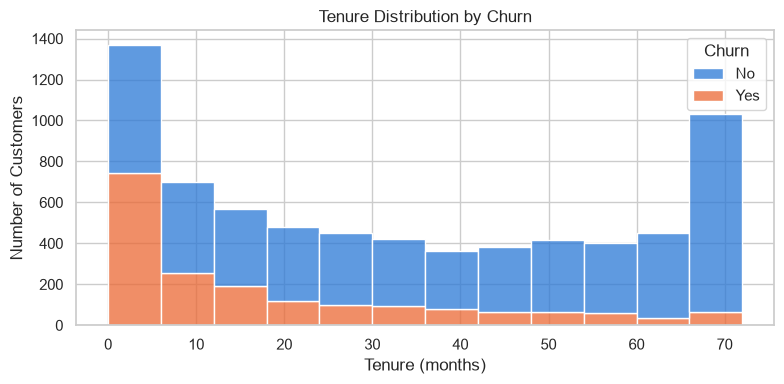

In [7]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=12,
    multiple="stack",
    palette=CHURN_COLORS,
    edgecolor="white",
    linewidth=1,
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Churn is concentrated in the first year

Most cancellations are concentrated in the first 10–20 months of a customer's tenure. Customers who remain beyond that threshold almost never leave — the spike of non-churners at 70–72 months confirms that long-tenure customers are effectively retained. This makes tenure one of the most likely strong predictors in the model: it separates early at-risk customers from stable long-term ones cleanly.

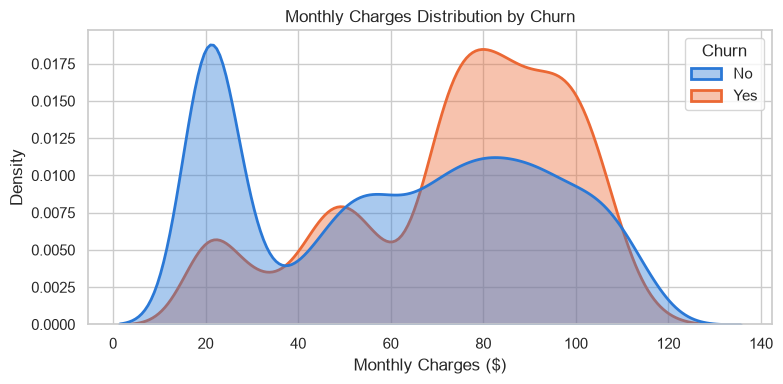

In [8]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    palette=CHURN_COLORS,
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### Higher monthly charges track with churn

Non-churning customers are concentrated in the lower monthly charge range (~$20), likely representing basic-plan users with minimal services. Churning customers skew heavily toward higher charges ($60–100+), suggesting that power users on premium plans are at greater churn risk.

This is counterintuitive but explainable — high-charge customers tend to be on fiber optic internet with multiple add-ons, and that segment overlaps strongly with month-to-month contracts. The charge level itself is unlikely to cause churn directly; rather, both high charges and churn share a common driver in service type and contract flexibility.

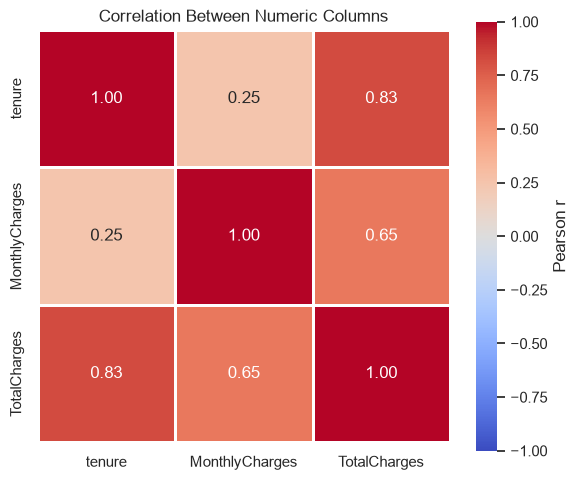

In [9]:
corr_data = df[["tenure", "MonthlyCharges", "TotalCharges"]].apply(
    pd.to_numeric,
    errors="coerce",
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Pearson r"},
)

plt.title("Correlation Between Numeric Columns")
plt.tight_layout()
plt.show()

### `TotalCharges` is redundant

TotalCharges shows strong correlation with tenure (0.83) and moderate correlation with MonthlyCharges (0.65), while tenure and MonthlyCharges are largely independent of each other (0.25). This is expected — total charges are approximately the product of tenure and monthly rate, making TotalCharges a derived variable rather than an independent signal.

Decision: drop TotalCharges before model training. tenure and MonthlyCharges capture the same information independently and without redundancy. Keeping all three would introduce collinearity that destabilises feature weights without adding predictive value.